# Hermite Basis Functions Demo
This notebook demonstrates Hermite basis functions and their visualization using Julia and Plots.

In [1]:
using Plots, LaTeXStrings

## Define Hermite shape functions
Define the four Hermite basis functions as anonymous functions.

In [2]:
θHermite = [
    ξ -> 2ξ^3 - 3ξ^2 + 1, # θHermite[i] = θ_{i-1}
    ξ -> -2ξ^3 + 3ξ^2,
    ξ -> ξ^3 - 2ξ^2 + ξ,
    ξ -> ξ^3 - ξ^2,
]

4-element Vector{Function}:
 #11 (generic function with 1 method)
 #12 (generic function with 1 method)
 #13 (generic function with 1 method)
 #14 (generic function with 1 method)

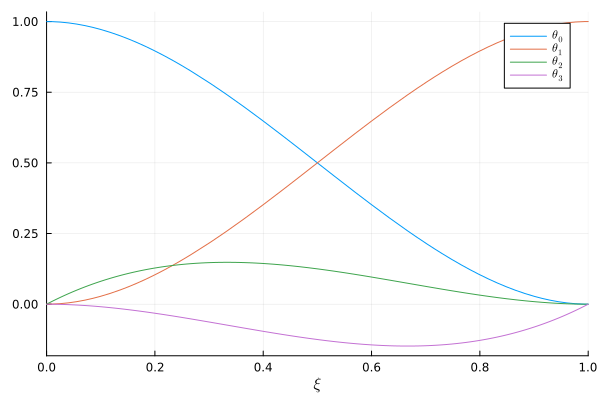

In [8]:
plot(xlim = (0, 1), xlabel = L"\xi")
for i = 1:4
    plot!(ξ -> θHermite[i](ξ), label = latexstring("\\theta_{$(i-1)}"))
end
plot!()

In [ ]:
savefig("Hermite_reference_element.png")

## Basis function of $H^2$ in a mesh

### Functions $v$ that "glue" with value $1$ and derivative $0$
Define the mesh and the function `v(i, x)` for piecewise Hermite functions.

In [4]:
mesh = [-Inf, 0.0, 0.1, 0.2, 0.4, 0.5, +Inf]
function v(i::Integer, x::Real)
    if x >= mesh[i-1] && x < mesh[i]
        ξ = (x - mesh[i-1]) / (mesh[i] - mesh[i-1])
        return θHermite[2](ξ)
    elseif x >= mesh[i] && x < mesh[i+1]
        ξ = (x - mesh[i]) / (mesh[i+1] - mesh[i])
        return θHermite[1](ξ)
    else
        return 0.0
    end
end

v (generic function with 1 method)

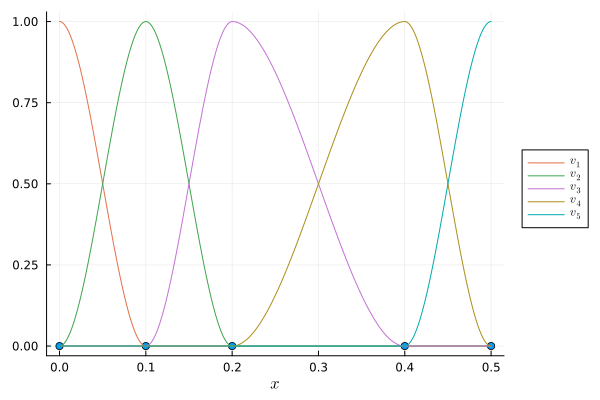

In [9]:
scatter(mesh[2:end-1], zeros(size(mesh[2:end-1])), label = "", leg = :outerright)
for i = 2:length(mesh)-1
    plot!(x -> v(i, x), label = latexstring("v_{$(i-1)}"))
end
xlabel!(L"x")

In [ ]:
savefig("Hermite_interval_v.png")

### Functions $w$ that "glue" with value $0$ and derivative $1$

Define the function w(i, x) using θHermite[3] and θHermite[4] with mesh-dependent scaling.

In [6]:
function w(i::Integer, x::Real)
    if x >= mesh[i-1] && x < mesh[i]
        dx = mesh[i] - mesh[i-1]
        ξ = (x - mesh[i-1]) / dx
        return dx * θHermite[4](ξ)
    elseif x >= mesh[i] && x < mesh[i+1]
        dx = mesh[i+1] - mesh[i]
        ξ = (x - mesh[i]) / dx
        return dx * θHermite[3](ξ)
    else
        return 0.0
    end
end

w (generic function with 1 method)

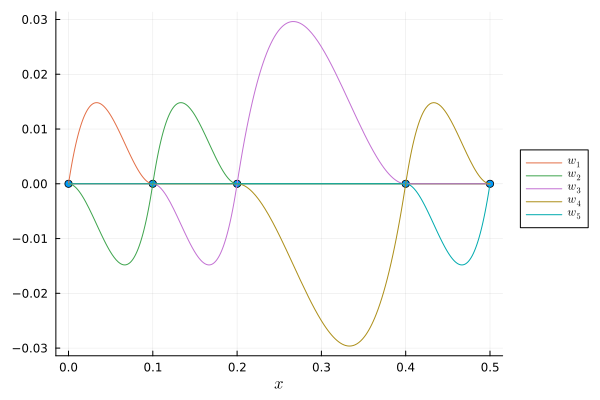

In [10]:
scatter(mesh[2:end-1], zeros(size(mesh[2:end-1])), label = "", leg = :outerright)
for i = 2:length(mesh)-1
    plot!(x -> w(i, x), label = latexstring("w_{$(i-1)}"))
end
xlabel!(L"x")


In [ ]:
savefig("Hermite_interval_w.png")